# Emissions and Climate Impact
### How do CO<sub>2</sub> emissions correlate with global temperature anomalies?

In [27]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import scipy.stats as stats

In [3]:
# Loading the dataset
temp = pd.read_csv(r'C:\Users\jpaul\OneDrive\Documents\Climate_Study\GLB.Ts+dSST.csv')
emissions = pd.read_csv(r'C:\Users\jpaul\OneDrive\Documents\Climate_Study\cleaned_owid_co2_data.csv')

In [4]:
# Create our dataframe.
df = pd.merge(emissions, temp, on='Year')
df.head()

,country,Year,iso_code,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,...,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,Afghanistan,1949,AFG,7356890.0,0.0,0.0,0.015,NaN,NaN,6.250,...,-0.14,-0.07,-0.1,-0.18,-0.11,-0.12,-0.1,-0.08,-0.18,-0.1
1,Afghanistan,1950,AFG,7776182.0,0.0,0.0,0.084,0.070,475.000,7.316,...,-0.12,-0.2,-0.34,-0.22,-0.18,-0.17,-0.24,-0.13,-0.1,-0.22
2,Afghanistan,1951,AFG,7879343.0,0.0,0.0,0.092,0.007,8.696,8.264,...,0.05,0.08,-0.01,0.15,-0.07,-0.1,-0.33,-0.12,-0.01,0.04
3,Afghanistan,1952,AFG,7987783.0,0.0,0.0,0.092,0.000,0.000,9.192,...,0.07,0,-0.13,-0.02,0.01,0.02,0.13,-0.03,0.02,-0.02
4,Afghanistan,1953,AFG,8096703.0,0.0,0.0,0.106,0.015,16.000,10.269,...,0.04,0.08,-0.03,0.05,0.08,0.07,0.07,0.14,0.06,0.03


In [5]:
# Checking for duplicate rows.
duplicates = df[df.duplicated()]
num_duplicates = duplicates.shape[0]

print(f'There are {num_duplicates} duplicate rows.')

There are 0 duplicate rows.


In [6]:
# Strip the columns of white spaces.
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns: 
    df[col] = df[col].str.strip()

In [7]:
# Missing Values.
df_miss = df.dropna(inplace=True)

df.head()

,country,Year,iso_code,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,...,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
1,Afghanistan,1950,AFG,7776182.0,0.0,0.0,0.084,0.070,475.000,7.316,...,-0.12,-0.2,-0.34,-0.22,-0.18,-0.17,-0.24,-0.13,-0.1,-0.22
2,Afghanistan,1951,AFG,7879343.0,0.0,0.0,0.092,0.007,8.696,8.264,...,0.05,0.08,-0.01,0.15,-0.07,-0.1,-0.33,-0.12,-0.01,0.04
3,Afghanistan,1952,AFG,7987783.0,0.0,0.0,0.092,0.000,0.000,9.192,...,0.07,0,-0.13,-0.02,0.01,0.02,0.13,-0.03,0.02,-0.02
4,Afghanistan,1953,AFG,8096703.0,0.0,0.0,0.106,0.015,16.000,10.269,...,0.04,0.08,-0.03,0.05,0.08,0.07,0.07,0.14,0.06,0.03
5,Afghanistan,1954,AFG,8207953.0,0.0,0.0,0.106,0.000,0.000,11.137,...,-0.1,-0.02,0.08,-0.18,-0.13,-0.11,-0.1,-0.16,-0.18,-0.01


In [8]:
# Filtering the emissions. 
emissions_filtered = emissions[emissions['country'] == 'World'][['Year', 'co2']]
emissions_filtered = emissions_filtered.rename(columns={'co2': 'CO2_emissions'})

df = pd.merge(emissions_filtered, temp, on='Year', how='inner')

df.head()


,Year,CO2_emissions,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,858.056,-0.19,-0.25,-0.09,-0.17,-0.1,-0.21,-0.19,-0.11,-0.15,-0.24,-0.22,-0.18,-0.17,***,***,-0.12,-0.17,-0.2
1,1881,887.965,-0.20,-0.14,0.03,0.05,0.06,-0.19,0,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.1,-0.17,0.04,-0.08,-0.19
2,1882,937.888,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.11,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,997.515,-0.29,-0.37,-0.12,-0.19,-0.18,-0.07,-0.08,-0.14,-0.22,-0.12,-0.24,-0.11,-0.18,-0.2,-0.34,-0.16,-0.1,-0.2
4,1884,1009.430,-0.13,-0.08,-0.36,-0.4,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29


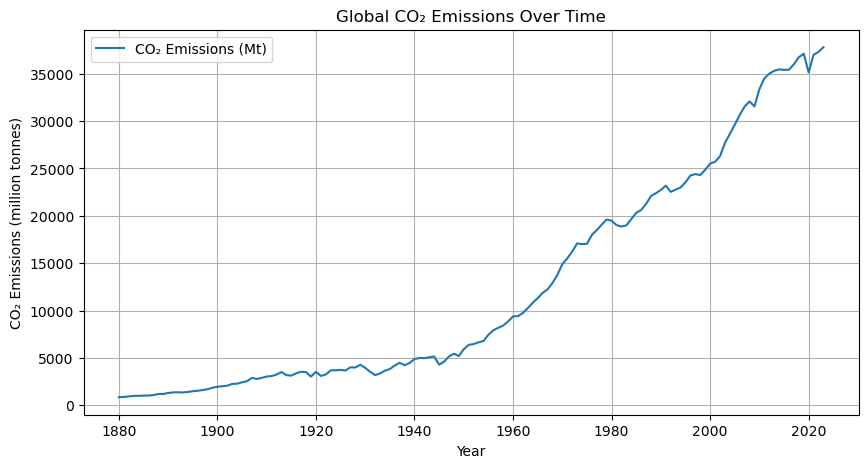

In [9]:
# Scatter plat of CO2 over time.
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['CO2_emissions'], label='CO₂ Emissions (Mt)')
plt.title("Global CO₂ Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (million tonnes)")
plt.grid(True)
plt.legend()
plt.show()


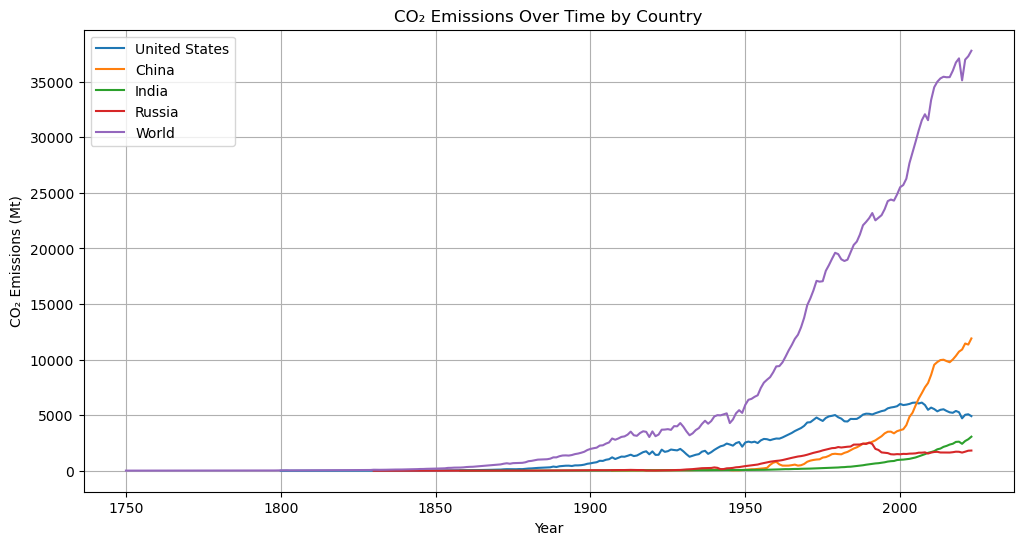

In [10]:
# Viewing emissions per country 
countries_of_interest = ['United States', 'China', 'India', 'Russia', 'World']
emissions_subset = emissions[emissions['country'].isin(countries_of_interest)]

plt.figure(figsize=(12,6))
for country in countries_of_interest:
    subset = emissions_subset[emissions_subset['country'] == country]
    plt.plot(subset['Year'], subset['co2'], label=country)

plt.title("CO₂ Emissions Over Time by Country")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
monthly_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df[monthly_columns] = df[monthly_columns].apply(pd.to_numeric, errors='coerce')

df['temp_anomaly'] = df[monthly_columns].mean(axis=1, skipna=True)

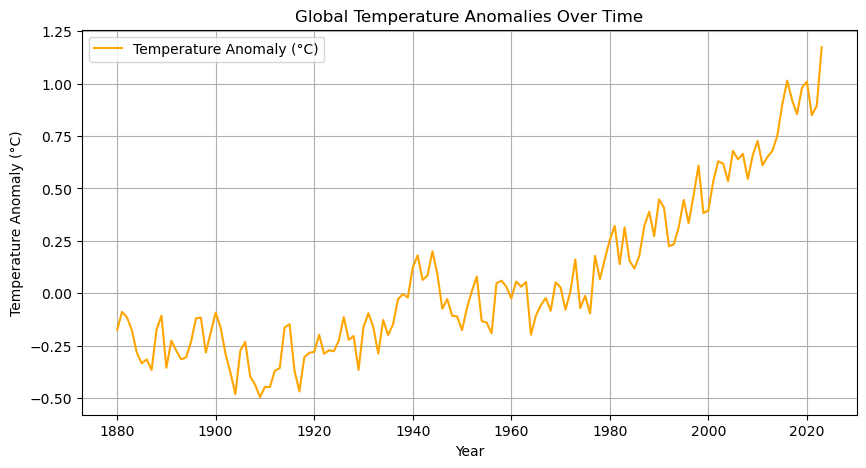

In [12]:

# Viewing the temperatures over time.
plt.figure(figsize=(10,5))
plt.plot(df['Year'], df['temp_anomaly'], color='orange', label='Temperature Anomaly (°C)')
plt.title("Global Temperature Anomalies Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.legend()
plt.show()


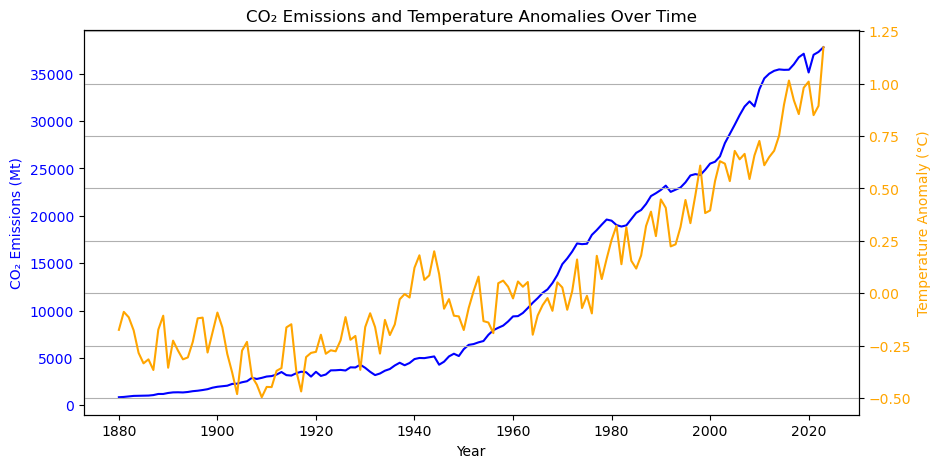

In [13]:
# Checking the trends of both temperature and emissions.
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.set_xlabel('Year')
ax1.set_ylabel('CO₂ Emissions (Mt)', color='blue')
ax1.plot(df['Year'], df['CO2_emissions'], color='blue', label='CO₂ Emissions')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()  # Create second y-axis
ax2.set_ylabel('Temperature Anomaly (°C)', color='orange')
ax2.plot(df['Year'], df['temp_anomaly'], color='orange', label='Temperature Anomaly')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("CO₂ Emissions and Temperature Anomalies Over Time")
plt.grid(True)
plt.show()


In [14]:
# Correlation of emmissions and temp_anomaly.
correlation = df['CO2_emissions'].corr(df['temp_anomaly'])
print(f"Pearson correlation: {correlation:.3f}")


Pearson correlation: 0.934


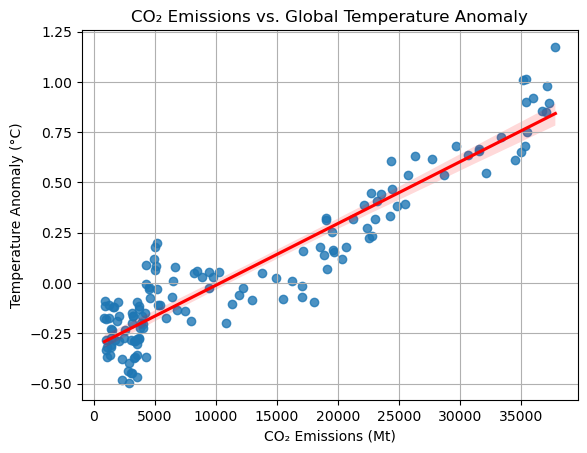

In [15]:
# sns.regplot(data=df, x='CO2_emissions', y='temp_anomaly')
sns.regplot(
    data=df,
    x='CO2_emissions',
    y='temp_anomaly',
    line_kws={'color': 'red'}
)

plt.title('CO₂ Emissions vs. Global Temperature Anomaly')
plt.xlabel('CO₂ Emissions (Mt)')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.show()



# Simple Linear Regression.


In [16]:
# Add constant for intercept
X = sm.add_constant(df['CO2_emissions'])  # X needs to be 2D
y = df['temp_anomaly']

# Fit the model
model = sm.OLS(y, X).fit()

# Print full summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           temp_anomaly   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     964.2
Date:                Fri, 02 May 2025   Prob (F-statistic):           3.59e-65
Time:                        08:24:34   Log-Likelihood:                 82.564
No. Observations:                 144   AIC:                            -161.1
Df Residuals:                     142   BIC:                            -155.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.3176      0.017    -18.885

Regression equation: y = 0.0000307127x + -0.3176


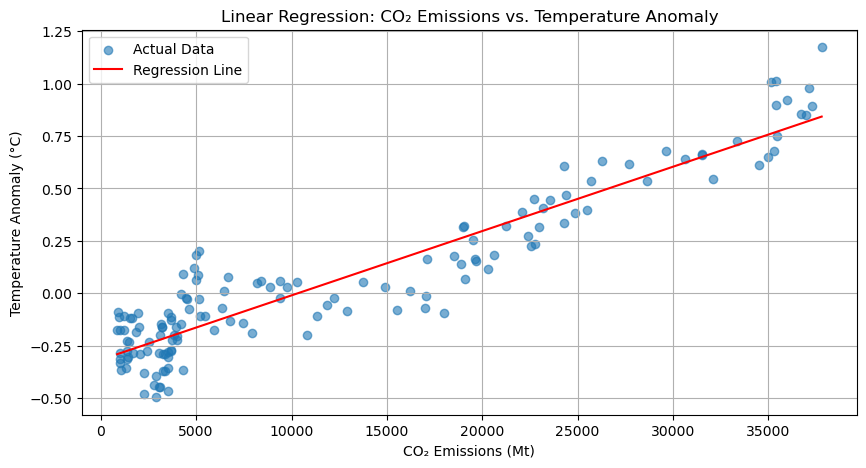

R² score: 0.8716
Mean Squared Error: 0.0186


In [17]:
# Preparing the data. 
X = df['CO2_emissions'].values.reshape(-1, 1)  # Feature matrix (2D)
y = df['temp_anomaly'].values  # Target array (1D)

# Create & Fit the Model.
model = LinearRegression()
model.fit(X, y)

# Model Output.
slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression equation: y = {slope:.10f}x + {intercept:.4f}")

# Make Predictions.
y_pred = model.predict(X)

#Fancy Scatter plot for pizzazz. 
plt.figure(figsize=(10,5))
plt.scatter(X, y, alpha=0.6, label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.title("Linear Regression: CO₂ Emissions vs. Temperature Anomaly")
plt.xlabel("CO₂ Emissions (Mt)")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the Model.
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R² score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")





# Multivariate Regression.

In [23]:
# Filtering emissions data. 
cols_to_keep = ['Year', 'co2', 'methane', 'nitrous_oxide', 'land_use_change_co2']
emissions_filtered = emissions[emissions['country'] == 'World'][cols_to_keep]
emissions_filtered = emissions_filtered.rename(columns={'co2': 'CO2_emissions'})

# Re-merging with temperature.
df = pd.merge(emissions_filtered, temp, on='Year', how='inner')

# If you're using monthly anomalies:
monthly_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df[monthly_columns] = df[monthly_columns].apply(pd.to_numeric, errors='coerce')
df['temp_anomaly'] = df[monthly_columns].mean(axis=1, skipna=True)


In [24]:
# Running the multivariate regression.
import statsmodels.api as sm

predictors = ['CO2_emissions', 'methane', 'nitrous_oxide', 'land_use_change_co2']
df_multi = df[['temp_anomaly'] + predictors].dropna()

X = sm.add_constant(df_multi[predictors])  # add intercept
y = df_multi['temp_anomaly']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           temp_anomaly   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     255.6
Date:                Fri, 02 May 2025   Prob (F-statistic):           5.19e-63
Time:                        08:31:05   Log-Likelihood:                 87.612
No. Observations:                 144   AIC:                            -165.2
Df Residuals:                     139   BIC:                            -150.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.4205    

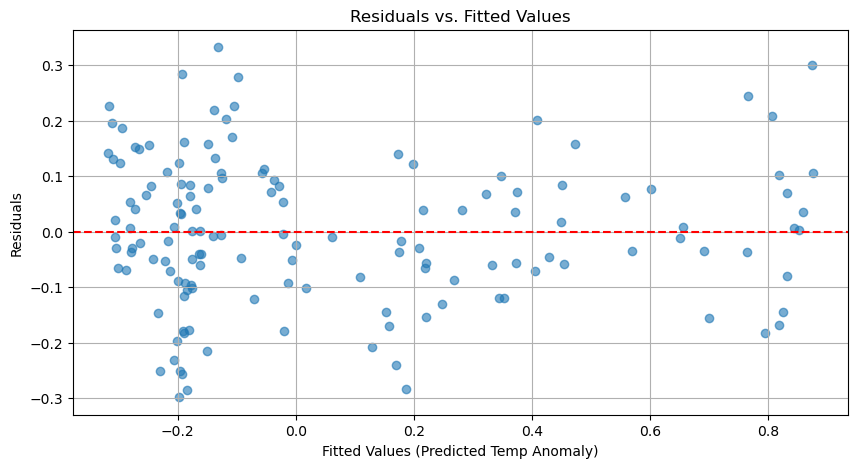

In [25]:
# Visualizing the residuals. 
# Predict values and calculate residuals
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(10, 5))
plt.scatter(fitted_vals, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs. Fitted Values")
plt.xlabel("Fitted Values (Predicted Temp Anomaly)")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

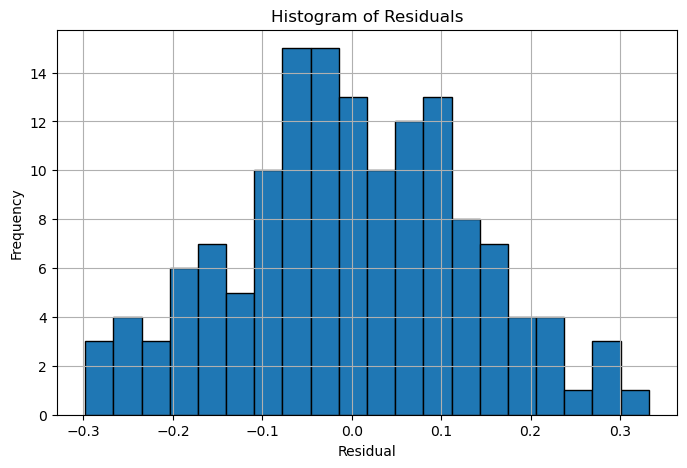

In [26]:
# Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor='k')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


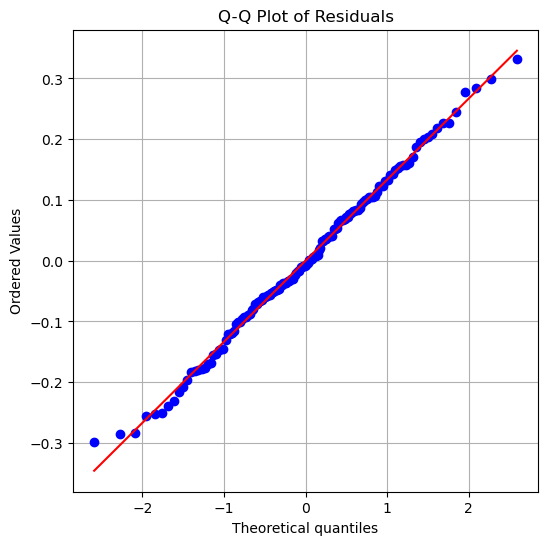

In [28]:
# Q-Q Plot. 
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.grid(True)
plt.show()